In [13]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "seaborn", "iminuit", "scikit-learn", "scipy"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from iminuit import Minuit, describe
from iminuit.util import make_func_code
from scipy.stats.distributions import chi2 as chi2_dist
warnings.simplefilter("ignore")

# Load experiment measurement files
exp1m1_df = pd.read_csv('data/exp1m1.csv')
exp1m2_df = pd.read_csv('data/exp1m2.csv')
exp1m3_df = pd.read_csv('data/exp1m3.csv')
exp1m4_df = pd.read_csv('data/exp1m4.csv')
exp1m5_df = pd.read_csv('data/exp1m5.csv')


In [14]:
class Chi2Reg:
    def __init__(self, model, x, y, dx=None, dy=None):
        self.model = model
        self.x = np.asarray(x)
        self.y = np.asarray(y)
        self.dx = np.zeros(len(x)) if dx is None else np.asarray(dx)
        if dy is None:
            raise ValueError("Uncertainties on y were not provided!")
        self.dy = np.asarray(dy)
        from iminuit.util import make_func_code, describe
        self.func_code = make_func_code(describe(self.model)[1:])
        self.h = (x[-1] - x[0]) / 10000

    def __call__(self, *par):
        ym = self.model(self.x, *par)
        df = (self.model(self.x + self.h, *par) - ym) / self.h
        return np.sum((self.y - ym) ** 2 / (self.dy ** 2 + (df * self.dx) ** 2))


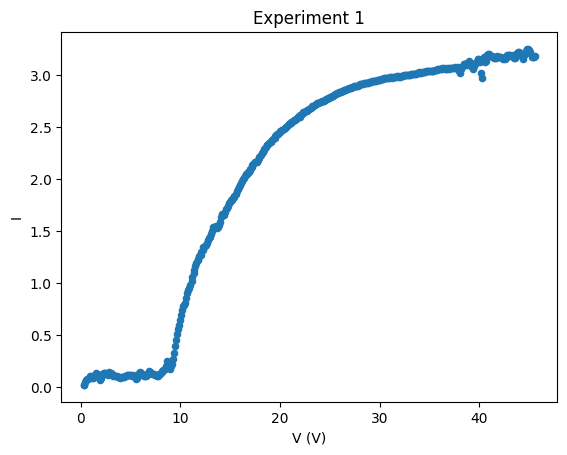

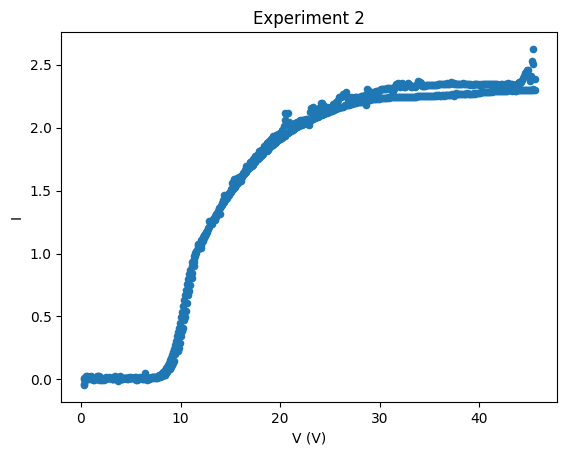

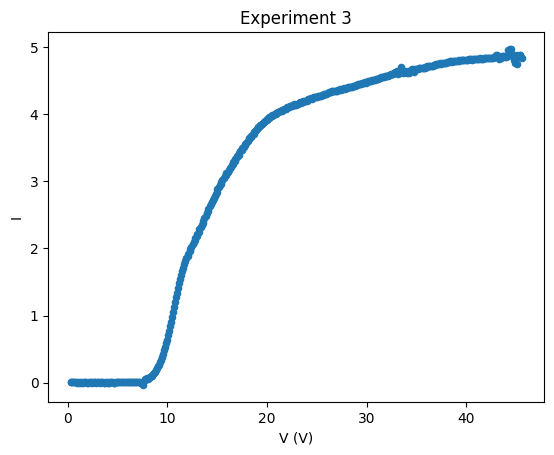

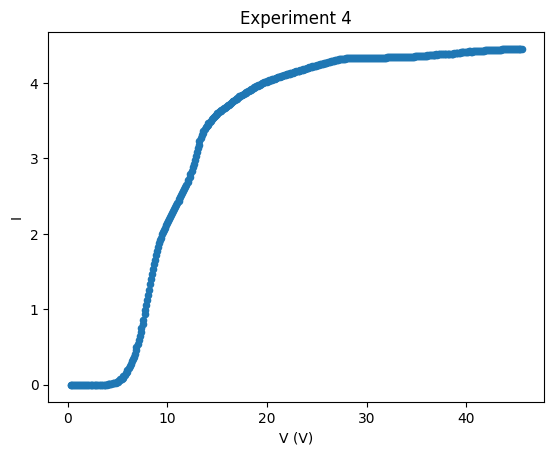

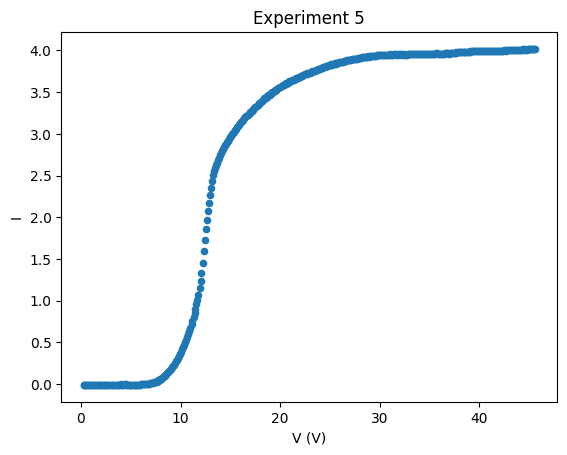

In [15]:
# Plot all measurements
experiment_dfs = [exp1m1_df, exp1m2_df, exp1m3_df, exp1m4_df, exp1m5_df]

for i, df in enumerate(experiment_dfs):
    df.plot(x='V', y='I', kind='scatter', title=f'Experiment {i+1}')
    plt.xlabel('V (V)')
    plt.ylabel('I')
    plt.show()


In [16]:
child_young_func = lambda v,k, vc:  k*((v+vc)**1.5)

In [17]:
def get_points_between_voltages(vi_df, starting_voltage, ending_voltage):
    return vi_df[(vi_df['V'] >= starting_voltage) & (vi_df['V'] <= ending_voltage)]


In [18]:
def get_chi2_for_voltage_range(vi_df,starting_voltage, ending_voltage,dI,multiplier, dv=None):
  truncated_data = get_points_between_voltages(vi_df,starting_voltage, ending_voltage)
  if truncated_data.empty:
    #print(f"Skipping start_point={start_point} because truncated_data is empty (range from {start_point} to {best_end_point} is invalid or empty).")
    return None
  v = truncated_data['V'].to_numpy() # Convert Series to numpy array
  if len(v) <= 2: # less data than parameters
    return 0
  I = truncated_data['I'].to_numpy()*multiplier # Convert Series to numpy array
  if dv is None:
    dv = [0.01*10**-3] * len(I)



  cost = Chi2Reg(child_young_func, v, I, dy=[dI]*len(I), dx=dv)
  m = Minuit(cost, k=1, vc=0)
  m.migrad()
  current_chi2_ndof = m.fval/(len(v)-m.nfit)
  return current_chi2_ndof

In [19]:
def get_all_posible_ranges_chi2(vi_df,starting_voltage, ending_voltage,dI,multiplier, range=5,):
  results_df = pd.DataFrame(columns=['starting_voltage', 'ending_voltage', 'chi2_ndof'])
  all_voltage_points_in_range = vi_df[(vi_df['V'] >= starting_voltage) & (vi_df['V'] <= ending_voltage)]['V'].unique()
  possible_starts = all_voltage_points_in_range[all_voltage_points_in_range <= starting_voltage+range]

  possible_ends = all_voltage_points_in_range[all_voltage_points_in_range >= ending_voltage-range]

  for starting_point in possible_starts:
    for end_point in possible_ends:
      results_df.loc[len(results_df)] = [starting_point, end_point, get_chi2_for_voltage_range(vi_df,starting_point, end_point,dI, multiplier)]
  return results_df

In [20]:
def get_best_range(vi_df,starting_voltage, ending_voltage,dI, multiplier,range=5,heatmap=False):
  results_df = get_all_posible_ranges_chi2(vi_df,starting_voltage, ending_voltage,dI,multiplier, range=range)
  if heatmap:
    plt.figure(figsize=(10, 6))
    sns.heatmap(results_df.pivot(index='starting_voltage', columns='ending_voltage', values='chi2_ndof'), annot=False, fmt=".2f", cmap="PuRd_r", vmin=0, vmax=45)
  best_row = results_df.loc[(results_df['chi2_ndof'] -1).abs().idxmin()]
  return best_row

In [21]:
def calculate_dI(vi_df, multiplier,dead_zone_start=2, dead_zone_end=8):
  dead_data = vi_df[(vi_df['V'] >= dead_zone_start) & (vi_df['V'] <= dead_zone_end)]
  return dead_data['I'].std() * multiplier

In [22]:
dI1 = calculate_dI(exp1m1_df,50)
dI2 = calculate_dI(exp1m2_df,1)
dI3 = calculate_dI(exp1m3_df,5)
dI4 = calculate_dI(exp1m4_df,1, dead_zone_start=2, dead_zone_end=5)
dI5 = calculate_dI(exp1m5_df,500)

starting_voltage    14.563000
ending_voltage      19.044000
chi2_ndof            0.999208
Name: 2220, dtype: float64

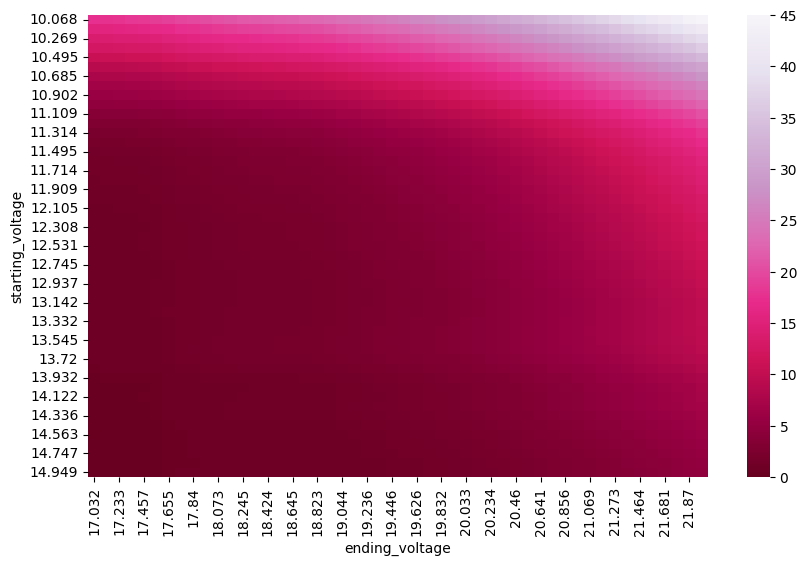

In [23]:
get_best_range(exp1m1_df,10,22,dI1,50, heatmap=True)

In [24]:
get_best_range(exp1m2_df,10,15,dI2,1,range=2)

starting_voltage    11.707000
ending_voltage      13.843000
chi2_ndof            3.886379
Name: 1143, dtype: float64

In [25]:
get_best_range(exp1m3_df,10,22,dI3,5,range=5)

starting_voltage    14.949000
ending_voltage      18.541000
chi2_ndof            0.996879
Name: 2415, dtype: float64

In [26]:
get_best_range(exp1m4_df,10,22,dI4,1,range=4)

starting_voltage    13.930000
ending_voltage      18.073000
chi2_ndof            2.174982
Name: 1520, dtype: float64

In [27]:
get_best_range(exp1m5_df,10,22,dI5,500,range=4)

starting_voltage    13.927000
ending_voltage      18.073000
chi2_ndof            2.284422
Name: 1520, dtype: float64